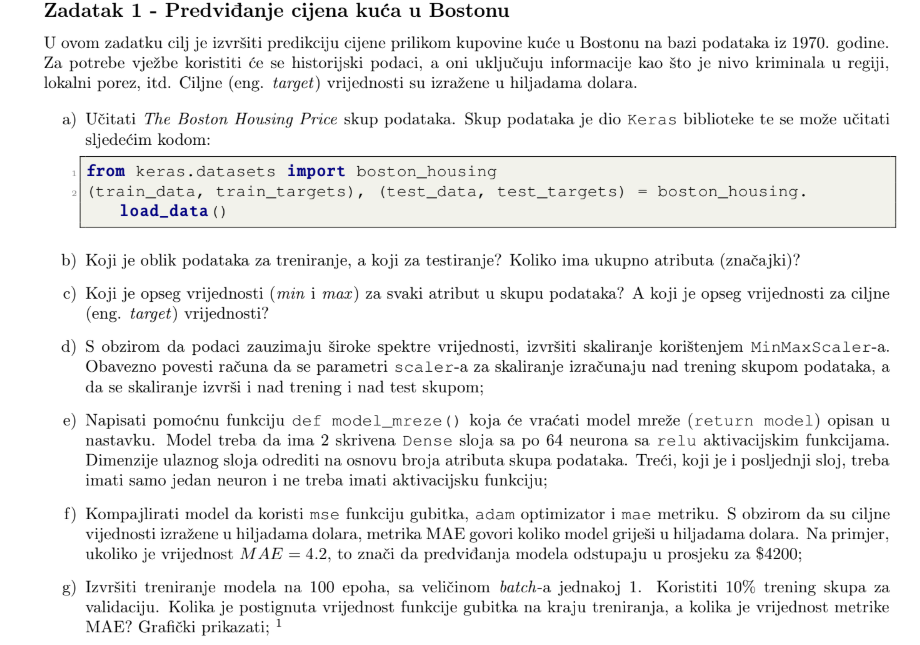

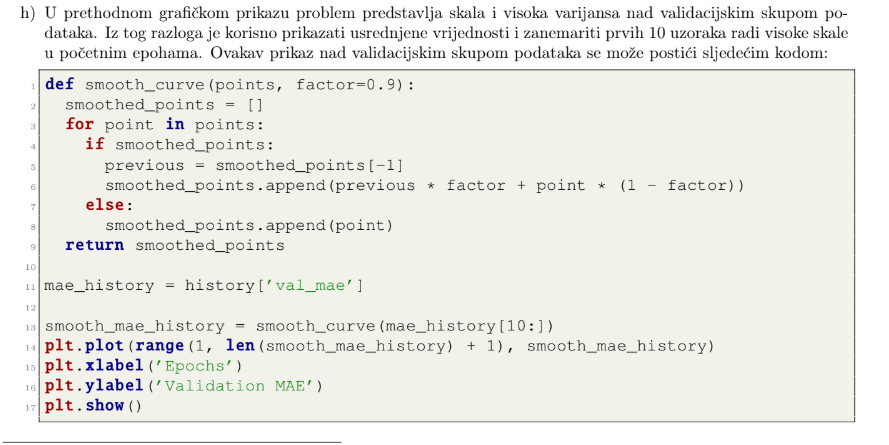

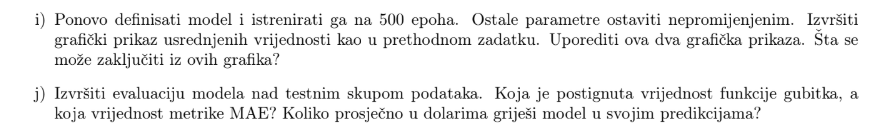

In [1]:
# a

from keras.datasets import boston_housing
from keras import models
from keras import layers

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

print(train_data.shape)
print(test_data.shape)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(404, 13)
(102, 13)


In [2]:
# b

print(train_data.shape)
print(test_data.shape)

print(train_data.shape[1])

(404, 13)
(102, 13)
13


In [3]:
# c

print(train_data.min(axis=0))
print(train_data.max(axis=0))

print(train_targets.min())
print(train_targets.max())

[6.3200e-03 0.0000e+00 4.6000e-01 0.0000e+00 3.8500e-01 3.5610e+00
 2.9000e+00 1.1296e+00 1.0000e+00 1.8800e+02 1.2600e+01 3.2000e-01
 1.7300e+00]
[ 88.9762 100.      27.74     1.       0.871    8.725  100.      10.7103
  24.     711.      22.     396.9     37.97  ]
5.0
50.0


In [4]:
# d

scaler = MinMaxScaler()

train_data_scaled = scaler.fit_transform(train_data)

test_data_scaled = scaler.transform(test_data)

print(train_data_scaled[:5])

[[1.37816304e-02 0.00000000e+00 2.81524927e-01 0.00000000e+00
  3.14814815e-01 4.99806352e-01 9.14521112e-01 2.97191228e-01
  1.30434783e-01 2.27533461e-01 8.93617021e-01 1.00000000e+00
  4.68818985e-01]
 [1.73654275e-04 8.25000000e-01 5.75513196e-02 0.00000000e+00
  6.17283951e-02 7.84082107e-01 1.31822863e-01 5.36536996e-01
  4.34782609e-02 3.05927342e-01 2.23404255e-01 9.96167230e-01
  3.80794702e-02]
 [5.49837765e-02 0.00000000e+00 6.46627566e-01 0.00000000e+00
  5.06172840e-01 2.72850503e-01 1.00000000e+00 2.11779933e-02
  1.00000000e+00 9.13957935e-01 8.08510638e-01 9.46089061e-01
  4.22185430e-02]
 [3.74171574e-04 0.00000000e+00 1.73387097e-01 0.00000000e+00
  2.67489712e-01 4.79473277e-01 3.25437693e-01 5.06821005e-01
  1.73913043e-01 6.88336520e-02 8.08510638e-01 1.00000000e+00
  1.73289183e-01]
 [4.14386307e-02 0.00000000e+00 6.46627566e-01 0.00000000e+00
  6.74897119e-01 5.45120062e-01 8.80535530e-01 1.50041229e-01
  1.00000000e+00 9.13957935e-01 8.08510638e-01 9.86207070e-0

In [5]:
# e

def model_mreze():

    model = models.Sequential()

    model.add(layers.Dense(
        64,
        activation='relu',
        input_shape=(train_data.shape[1],)
    ))

    model.add(layers.Dense(
        64,
        activation='relu'
    ))

    model.add(layers.Dense(1))

    return model

In [6]:
# f

model = model_mreze()

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 200.6685 - mae: 10.8356 - val_loss: 30.6052 - val_mae: 4.4774
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54.5699 - mae: 5.2288 - val_loss: 22.9421 - val_mae: 3.6240
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39.6950 - mae: 4.4539 - val_loss: 19.2358 - val_mae: 3.3711
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.9324 - mae: 3.9091 - val_loss: 20.5606 - val_mae: 3.4281
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.6879 - mae: 3.6054 - val_loss: 20.5988 - val_mae: 3.3980
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.5670 - mae: 3.3270 - val_loss: 19.3976 - val_mae: 3.2772
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.8060 - mae: 3.1192 - val_loss: 18.0567 - val_mae: 3.0738
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18.7061 - mae: 2.9950 - val_loss: 16.3217 - val_mae: 2.9079
Epoch 9/100
363/363 ━━━━━━━━

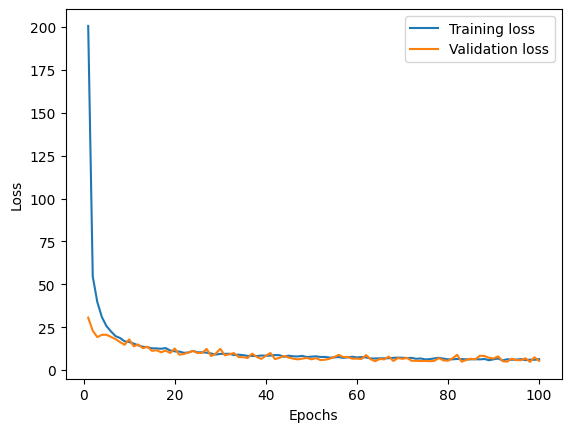

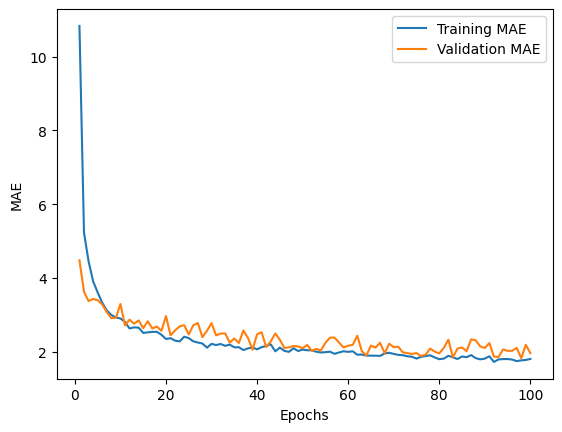

In [7]:
# g

history = model.fit(
    train_data_scaled,
    train_targets,
    epochs=100,
    batch_size=1,
    validation_split=0.1,
    verbose=1
)

print(history.history['loss'][-1])
print(history.history['mae'][-1])

print(history.history['val_loss'][-1])
print(history.history['val_mae'][-1])

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

mae = history.history['mae']
val_mae = history.history['val_mae']

plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')

plt.xlabel('Epochs')
plt.ylabel('MAE')

plt.legend()
plt.show()

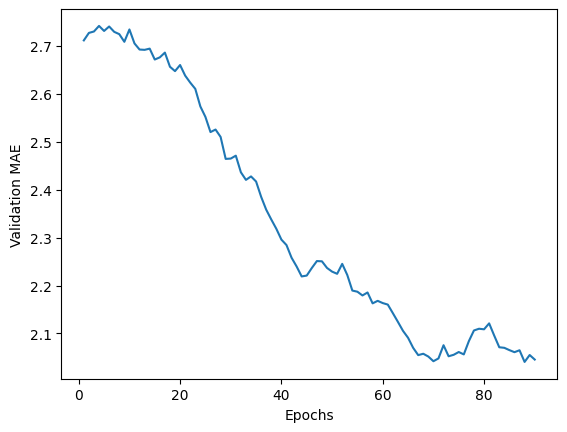

In [8]:
# h

def smooth_curve(points, factor=0.9):

    smoothed_points = []

    for point in points:

        if smoothed_points:

            previous = smoothed_points[-1]

            smoothed_points.append(
                previous * factor + point * (1 - factor)
            )

        else:
            smoothed_points.append(point)

    return smoothed_points


mae_history = history.history['val_mae']

smooth_mae_history = smooth_curve(mae_history[10:])

plt.plot(
    range(1, len(smooth_mae_history) + 1),
    smooth_mae_history
)

plt.xlabel('Epochs')
plt.ylabel('Validation MAE')

plt.show()

Epoch 1/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 204.7259 - mae: 10.8170 - val_loss: 34.7055 - val_mae: 4.8136
Epoch 2/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54.3185 - mae: 5.1827 - val_loss: 24.8983 - val_mae: 3.8995
Epoch 3/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37.8553 - mae: 4.3053 - val_loss: 22.6070 - val_mae: 3.6702
Epoch 4/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 29.4831 - mae: 3.8084 - val_loss: 25.2578 - val_mae: 3.8778
Epoch 5/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 25.3901 - mae: 3.6587 - val_loss: 19.9666 - val_mae: 3.2117
Epoch 6/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.7314 - mae: 3.3462 - val_loss: 24.5572 - val_mae: 3.5161
Epoch 7/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.2413 - mae: 3.4037 - val_loss: 21.3433 - val_mae: 3.2906
Epoch 8/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.8379 - mae: 3.2258 - val_loss: 22.7811 - val_mae: 3.4382
Epoch 9/500
363/363 ━━━━━━━━━━

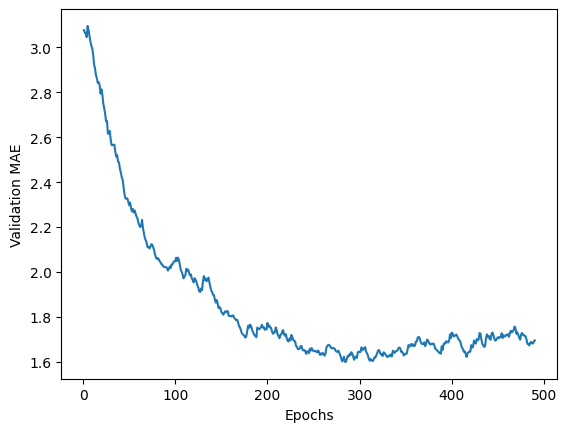

In [9]:
# i

model2 = model_mreze()

model2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history2 = model2.fit(
    train_data_scaled,
    train_targets,
    epochs=500,
    batch_size=1,
    validation_split=0.1,
    verbose=1
)

mae_history2 = history2.history['val_mae']

smooth_mae_history2 = smooth_curve(mae_history2[10:])

plt.plot(
    range(1, len(smooth_mae_history2) + 1),
    smooth_mae_history2
)

plt.xlabel('Epochs')
plt.ylabel('Validation MAE')

plt.show()

In [10]:
# j

test_mse_score, test_mae_score = model2.evaluate(
    test_data_scaled,
    test_targets
)

print(test_mse_score)
print(test_mae_score)

print(test_mae_score * 1000)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13.2283 - mae: 2.2662 
13.228320121765137
2.2661523818969727
2266.1523818969727
